## Title: Probing Interrogative Intent: mLLM embeddings for question similarity

##### Abstract
Semantic Textual Similarity tasks ...



### Introduction

- the context of the project and championing research questions. highlight the importance of mNLP and challenges in cross lingual representation

How do LLMs capture the semantic similarity of questions and their translations across different languages, is this representation sufficient to count as semantic capture, how do specific linguistic features of question sentences affect the similarity.

- state the problem of question semantics and classical propositional semantics: focus on interrogative sentences, and point out a different angle on STS tasks
  

- give a sketch of the approach and the hypotheses: using a mLLMs, generating embeddings, calculating cosine similairy and exploring patterns related to linguistic features

### Related work

- Discuss existing work on semantic textual similiarity, especially cross lingual STS

- discuss recent use of LLMs for semantic analysis and question analysis

- delimit the research gap: using an LLM to explore the cross-lingual semantic similarity of questions with linguistic features, as opposed to generic text similarity tasks




### Methodology

##### Dataset

##### Annotations

##### Embeddings

##### Similarity measures

##### Qualitative and Quantitative analysis


In [ ]:
# standard LLM pipeline


In [ ]:
# test analysis for usual STS tasks

In [ ]:
# code for the analysis


In [1]:
# import the required libraries
from sentence_transformers import SentenceTransformer # loads the model and generates embeddings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm as tqdm
from scipy import stats



In [14]:
# 1. Load data from data/encoded_test_data.csv

data = pd.read_csv('encoded_data.csv')

# 2. Load model from sentence transformers
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')


In [15]:
# generate embeddings for all examples in the data, one embedding per source question and one embedding per target question

print("Generating embeddings for source questions...")
source_embeddings = model.encode(data['source'].tolist(), show_progress_bar=True)

print('Generating embeddings for target questions...')
target_embeddings = model.encode(data['target'].tolist(), show_progress_bar=True)

# uncomment below print statements to see what the embeddings look like, ndim vector; only print one embedding at a time because of size issues

# print(f'source embedding:{source_embeddings[0]}')
# print(f'target embedding:{target_embeddings[0]}')

np.save('source_embeddings_miniLM.npy', source_embeddings)
np.save('target_embeddings_miniLM.npy', target_embeddings)




Generating embeddings for source questions...


Batches:   0%|          | 0/952 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [12]:
# calculate cosine similarity of all examples
similarities = []
for s_emb, t_emb in tqdm(zip(source_embeddings, target_embeddings)):
    sim = np.dot(s_emb, t_emb) / (np.linalg.norm(s_emb) * np.linalg.norm(t_emb))
    similarities.append(sim)


# augment the original data with the sim scores

data['cosine_similarity'] = similarities

data.to_csv('questions_similarities.csv')

print('Results of similarity analysis:')
print(data['cosine_similarity'].describe())

print("\nExample pairs from different similarity ranges:")
# high similarity
high_idx = np.argmax(similarities)
print(f"\nHighest similarity ({similarities[high_idx]:.3f}):")
print(f"Source ({data.iloc[high_idx]['language']}): {data.iloc[high_idx]['source']}")
print(f"Target: {data.iloc[high_idx]['target']}")

# medium similarity
med_idx = np.argsort(similarities)[len(similarities)//2]
print(f"\nMedian similarity ({similarities[med_idx]:.3f}):")
print(f"Source ({data.iloc[med_idx]['language']}): {data.iloc[med_idx]['source']}")
print(f"Target: {data.iloc[med_idx]['target']}")

# low similarity
low_idx = np.argmin(similarities)
print(f"\nLowest similarity ({similarities[low_idx]:.3f}):")
print(f"Source ({data.iloc[low_idx]['language']}): {data.iloc[low_idx]['source']}")
print(f"Target: {data.iloc[low_idx]['target']}")

# save just the data with similarities (not the big embeddings)
data.to_csv('questions_with_similarities_miniLM.csv')
print("\nSaved data with new similarities!")


500it [00:00, 79733.56it/s]

Results of similarity analysis:
count    500.000000
mean       0.843210
std        0.143460
min        0.106340
25%        0.784217
50%        0.896104
75%        0.943204
max        0.988594
Name: cosine_similarity, dtype: float64

Example pairs from different similarity ranges:

Highest similarity (0.989):
Source (id): Tetapi, bagaimana jika kita berpikir tentang makanan sebagai cara untuk benar-benar belajar lebih banyak tentang karyawan kita?
Target: But what if we thought about food as a way to really learn more about our employees?

Median similarity (0.896):
Source (id): Aku tidak membangun tempat ini, tapi ini semua adalah warisan ku …. hmmm, tempat ini adalah apa yang orang tua ku tinggalkan untuk ku, jadi apa jawaban mu?
Target: I did not construct this place, but it is all of my inheritance….hmmm, this place is what my parents left for me, so what’s your answer?

Lowest similarity (0.106):
Source (mr): आपण हे खरेदी करू शकता तेव्हा आम्हाला आपल्या स्वतः च्या हातांनी मत्स्यालय 

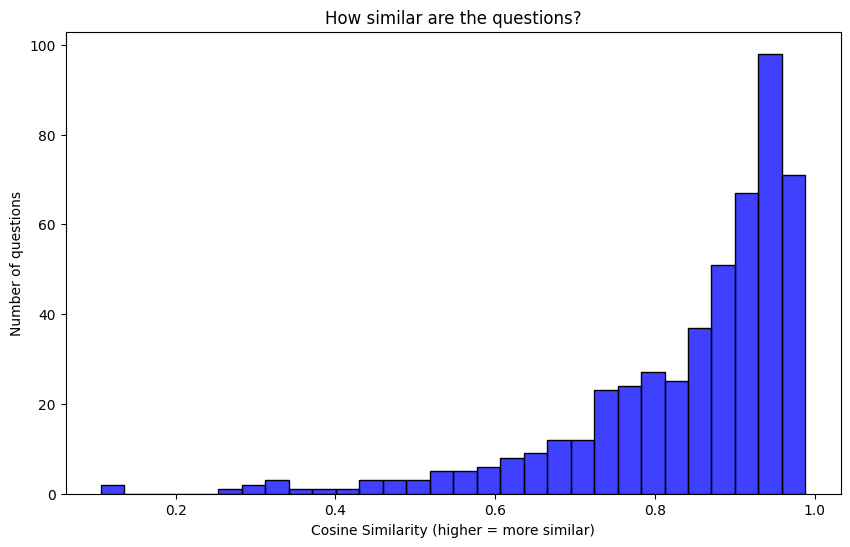

In [7]:
#visualizations

#similarity analysis
plt.figure(figsize=(10, 6))  # make the plot bigger
sns.histplot(data=data, x='cosine_similarity', bins=30, color='blue') 
plt.title('How similar are the questions?')
plt.xlabel('Cosine Similarity (higher = more similar)')
plt.ylabel('Number of questions')
plt.show()

### Results
include: avg similarity scores across different languages, average similarity scores for different linguistic features, correlation coefficients for feature/similarit results.

figures that visualize the distribution of scores and change wrt. feature and language

Intepret what similarity scores say about how model represents meaning, and the impact of features, analyse language specific trends, interesting examples

Limitations

